<div style="background:linear-gradient(135deg,#083344 0%,#0e7490 55%,#06b6d4 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#a5f3fc;font-weight:700;text-transform:uppercase">Chapter 88 · Case Study · Inference</div>
  <div style="font-size:33px;font-weight:900;line-height:1.1;margin:10px 0 6px">Case Study: Manufacturing Quality 🏭</div>
  <div style="font-size:15px;color:#ecfeff;max-width:760px;line-height:1.6">A factory line that looks on-target on average hides two real problems. We use a one-sample test against spec, an ANOVA across lines with Tukey, and a defect-by-shift chi-square to expose a drifting line and a risky night shift, and close the Part.</div>
  <div style="margin-top:16px;font-size:13px;color:#a5f3fc">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

## ⚙️ Setup

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats
CY="#0891b2"; DEEP="#0e7490"; LIGHT="#67e8f9"; INK="#1a2138"; GRID="#e6e9f2"; GREEN="#059669"; RED="#ef4444"; AMBER="#d97706"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
BASE="https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
rng = np.random.default_rng(88)

<div style="background:#ecfeff;border-left:5px solid #0891b2;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0e7490;letter-spacing:1px">STEP 1 · THE QUESTION & THE DATA</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Is the line on spec, and where are the defects?</div>
<div style="color:#4a5578;margin-top:6px">A plant fills packages to a 250 g target across three lines and two shifts, and logs any defects. Three questions: is the overall mean weight on target? do the three lines differ? and is the defect rate tied to shift? Quality control lives on these answers.</div>
</div>

In [2]:
try:    d = pd.read_excel("../../data/ch88_manufacturing_quality.xlsx", sheet_name="Units")
except FileNotFoundError: d = pd.read_excel(BASE+"ch88_manufacturing_quality.xlsx", sheet_name="Units")
print("loaded:", d.shape)
print(f"overall mean weight = {d.fill_weight_g.mean():.2f} g (target 250)")
print(d.groupby("line").fill_weight_g.mean().round(2))
print("defect rate by shift:", {k: round(v,3) for k,v in d.groupby(d["shift"]).defect.mean().items()})

loaded: (330, 6)
overall mean weight = 249.85 g (target 250)
line
Line-1    250.50
Line-2    248.67
Line-3    250.38
Name: fill_weight_g, dtype: float64
defect rate by shift: {'day': 0.06, 'night': 0.196}


The overall average looks fine, right near 250 g. But an aggregate can hide a drifting line, and defects may cluster by shift. We test all three questions before concluding the process is healthy.

<div style="background:#ecfeff;border-left:5px solid #0891b2;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0e7490;letter-spacing:1px">STEP 2 · THREE QUESTIONS, THREE TESTS</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Spec, lines, and defects</div>
<div style="color:#4a5578;margin-top:6px">Q1 mean weight vs a TARGET -> one-sample t-test against 250. Q2 weight across THREE lines -> one-way ANOVA (+Tukey). Q3 defect (yes/no) by shift -> chi-square / two-proportion. Each question's structure picks the tool.</div>
</div>

In [3]:
print("Q1 mean weight vs 250 g       -> ONE-SAMPLE t-test")
print("   H0: mu = 250                 H1: mu != 250")
print("Q2 weight across 3 lines        -> ONE-WAY ANOVA (+ Tukey)")
print("   H0: all line means equal     H1: a line differs")
print("Q3 defect rate by shift         -> CHI-SQUARE (shift x defect)")
print("   H0: defect independent of shift   H1: associated")

Q1 mean weight vs 250 g       -> ONE-SAMPLE t-test
   H0: mu = 250                 H1: mu != 250
Q2 weight across 3 lines        -> ONE-WAY ANOVA (+ Tukey)
   H0: all line means equal     H1: a line differs
Q3 defect rate by shift         -> CHI-SQUARE (shift x defect)
   H0: defect independent of shift   H1: associated


Notice Q1 (one target) and Q2 (compare lines) ask different things: the process can be on target ON AVERAGE while individual lines still drift in opposite directions and cancel out. That is exactly the trap we check for.

<div style="background:#ecfeff;border-left:5px solid #0891b2;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0e7490;letter-spacing:1px">STEP 3 · RUN THE ANALYSIS</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">One-sample, ANOVA + Tukey, and chi-square</div>
<div style="color:#4a5578;margin-top:6px">We test the overall mean against spec, compare the three lines (and locate any culprit with Tukey), then test whether defects depend on shift, reporting the defect rates and the expected-count check.</div>
</div>

In [4]:
w=d.fill_weight_g; q1=stats.ttest_1samp(w,250)
print(f"Q1 overall mean = {w.mean():.2f} g, t={q1.statistic:.2f}, p={q1.pvalue:.3f}  -> {'on target' if q1.pvalue>=0.05 else 'off target'}")
groups=[g.fill_weight_g.values for _,g in d.groupby("line")]; names=list(d.groupby("line").groups.keys())
F,p=stats.f_oneway(*groups)
print(f"Q2 ANOVA across lines: F={F:.2f}, p={p:.2e}  -> {'lines differ' if p<0.05 else 'lines equal'}")

Q1 overall mean = 249.85 g, t=-0.98, p=0.329  -> on target
Q2 ANOVA across lines: F=15.68, p=3.15e-07  -> lines differ


In [5]:
def tukey_hsd(groups, names, alpha=0.05):
    from scipy.stats import studentized_range
    k=len(groups); N=sum(len(g) for g in groups); dfw=N-k
    msw=sum(((g-g.mean())**2).sum() for g in groups)/dfw
    q=studentized_range.ppf(1-alpha, k, dfw)
    for i in range(k):
        for j in range(i+1,k):
            diff=groups[i].mean()-groups[j].mean(); hsd=q*np.sqrt(msw/2*(1/len(groups[i])+1/len(groups[j])))
            print(f"  {names[i]} vs {names[j]}: diff={diff:+.2f} g, differ={'YES' if abs(diff)>hsd else 'no'}")

Q2 Tukey (which line drifts?):
  Line-1 vs Line-2: diff=+1.83 g, differ=YES
  Line-1 vs Line-3: diff=+0.12 g, differ=no
  Line-2 vs Line-3: diff=-1.71 g, differ=YES
Q3 defect rate: day 6.0% vs night 19.6%; chi2=12.83, dof=1, p=0.0003, min expected=17.9
   -> reject H0: defects depend on shift


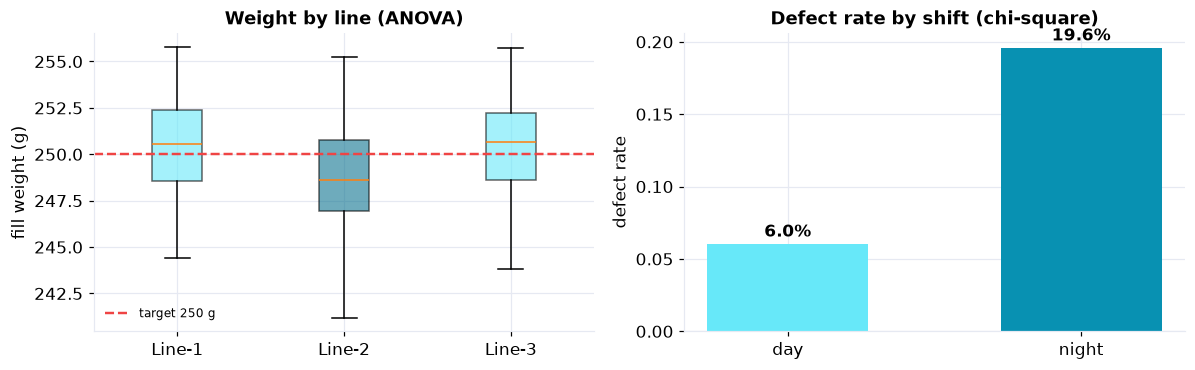

In [6]:
print("Q2 Tukey (which line drifts?):"); tukey_hsd(groups, names)
ct=pd.crosstab(d["shift"], d.defect)
chi2,p,dof,expected=stats.chi2_contingency(ct)
day=d[d["shift"]=="day"].defect.mean(); night=d[d["shift"]=="night"].defect.mean()
print(f"Q3 defect rate: day {day:.1%} vs night {night:.1%}; chi2={chi2:.2f}, dof={dof}, p={p:.4f}, min expected={expected.min():.1f}")
print("   -> reject H0: defects depend on shift" if p<0.05 else "   -> independent")
fig,ax=plt.subplots(1,2,figsize=(11,3.5))
order=["Line-1","Line-2","Line-3"]
bp=ax[0].boxplot([d[d.line==l].fill_weight_g.values for l in order], tick_labels=order, patch_artist=True)
for patch,l in zip(bp["boxes"],order): patch.set_facecolor(DEEP if l=="Line-2" else LIGHT); patch.set_alpha(0.6)
ax[0].axhline(250,color=RED,lw=1.6,ls="--",label="target 250 g"); ax[0].set_ylabel("fill weight (g)")
ax[0].set_title("Weight by line (ANOVA)"); ax[0].legend(fontsize=8)
ax[1].bar(["day","night"],[day,night],color=[LIGHT,CY],width=0.55)
for i,v in enumerate([day,night]): ax[1].text(i,v+0.005,f"{v:.1%}",ha="center",fontweight="bold")
ax[1].set_ylabel("defect rate"); ax[1].set_title("Defect rate by shift (chi-square)")
plt.tight_layout(); plt.show()

Here is the lesson in one dataset. The overall mean (249.85 g) is statistically <strong>on target</strong> (p &#8776; 0.33), but that is misleading: the ANOVA says the lines differ (F &#8776; 15.7, p &#8776; 10&#8315;&#8311;), and Tukey pins it on <strong>Line-2</strong>, which runs about 1.7 g light while Lines 1 and 3 sit slightly high, the errors cancel in the aggregate. Separately, the defect rate is <strong>three times higher at night</strong> (19.6% vs 6.0%, chi-square p &#8776; 0.0003). Two real, actionable problems hidden behind a healthy-looking average.

<div style="background:#ffffff;border:1px solid #cffafe;border-left:5px solid #0e7490;border-radius:12px;padding:18px 22px;font-family:Inter,sans-serif">
<div style="font-size:12px;font-weight:800;color:#0e7490;letter-spacing:1px">📋 STATISTICIAN’S REPORT</div>
<div style="font-size:18px;font-weight:800;color:#1a2138;margin:4px 0 8px">Findings: on-target on average, but two real problems</div>
<div style="color:#3f4a63;line-height:1.75"><strong>What we found.</strong> Overall the line hits its 250 g target on average, so a single headline number would say 'all good.' It is not. <strong>Line-2 is under-filling</strong> by about <strong>1.7 grams</strong> while Lines 1 and 3 run slightly heavy, the over- and under-fills cancel out in the average but are real. And <strong>defects are about three times more common on the night shift</strong> (about 20% vs 6%). <br><br><strong>How confident are we?</strong> The line difference is highly unlikely to be chance (less than 1 in a million), and the careful pairwise comparison isolates Line-2. The shift difference in defects is also clear (about 1 in 3,000 by chance). <br><br><strong>What to do.</strong> (1) Recalibrate Line-2's filler, it is giving away product on the heavy side elsewhere and risking under-weight complaints on Line-2. (2) Investigate the night shift: staffing, fatigue, lighting, or maintenance timing, the defect rate there is the bigger cost. <br><br><strong>Caveats.</strong> The on-target average is a reminder to monitor each line separately, not just the plant total; aggregate metrics can mask offsetting drift. This is a snapshot sample, set up ongoing control charts to catch drift as it happens.</div>
</div>

<div style="background:#ecfeff;border:1px solid #a5f3fc;border-radius:14px;padding:20px 24px;font-family:Inter,sans-serif">
<div style="font-size:18px;font-weight:800;color:#0e7490">🏁 That completes Part XIII</div>
<div style="color:#3f4a63;line-height:1.75;margin-top:6px">Across five case studies you have taken raw business questions, A/B tests, group comparisons, a clinical trial, a survey, and a factory line, and turned each into the right test, run correctly, reported with an effect size and an interval, and explained to a non-statistician. That is applied inference. Next the book turns to <strong>relationships between variables</strong>: correlation and regression.</div></div>

---
<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:10px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>